# Project 4 Extension — CNN-GRU for N2O Forecasting in Wastewater Treatment

## Introduction

This notebook extends Project 4 (GRU-based text generation) to a real-world
**multivariate time-series regression** task: forecasting nitrous oxide (N2O) emissions
in a full-scale wastewater treatment plant (WWTP).

We implement and compare two architectures:

| Model | Architecture |
|---|---|
| **Plain GRU** | GRU(64) → GRU(32) → Dense(1) |
| **CNN-GRU** | Conv1D(32) → Conv1D(64) → GRU(64) → GRU(32) → Dense(1) |

The CNN-GRU architecture follows Sajjad et al., *A Novel CNN-GRU-Based Hybrid Approach
for Short-Term Residential Load Forecasting*, IEEE Access 2020.

### Dataset — N2O WWTP (AVED)

The dataset is a 2-year (Jun 2022 – Jun 2024) record from a full-scale WWTP in Aved,
Denmark, sampled at 1-minute resolution (~830 K rows).  Nine physically correlated sensors
are selected as model features:

| Feature | Meaning |
|---|---|
| N2O | Nitrous-oxide concentration — **target** |
| NH4 | Ammonium — key N2O precursor |
| NO3 | Nitrate |
| O2 | Dissolved oxygen |
| TEMPERATURE | Biological process driver |
| BLOWER AIRFLOW | Aeration intensity |
| O2 SETPOINT | Control signal |
| SS | Suspended solids |
| PROCESSPHASE | Operational phase indicator |

A sliding window of **60 minutes** of history is used to predict the N2O value
**60 minutes into the future** (HORIZON = 60 steps). At this horizon, raw
autocorrelation breaks down and cross-sensor features (NH4, O2, airflow,
process phase) carry real predictive power — the regime where CNN-GRU's
feature mixing is expected to outperform a plain GRU.


---
## 1. Imports

In [9]:
import sys, os
#sys.path.insert(0, os.path.join(os.getcwd(), '..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler

from time_series_net import GRU_Regressor, CNN_GRU_Regressor

print('TensorFlow', tf.__version__)
print('NumPy', np.__version__)


TensorFlow 2.17.0
NumPy 1.26.4


---
## 2. Data Loading & Preprocessing

In [10]:
# Load the AVED WWTP dataset (only value columns; drop quality columns)
df_raw = pd.read_csv('data/aved_raw.csv', parse_dates=['time'], index_col='time')

# Select the 9 physically meaningful value columns
FEATURE_COLS = [
    'BIOLOGY.LINE 3 TANK 1.N2O value',          # target — also used autoregressively
    'BIOLOGY.LINE 3 TANK 1.NH4 value',           # ammonium
    'BIOLOGY.LINE 3 TANK 1.NO3 value',           # nitrate
    'BIOLOGY.LINE 3 TANK 1.O2 value',            # dissolved oxygen
    'BIOLOGY.LINE 3 TANK 1.TEMPERATURE value',   # temperature
    'BIOLOGY.BLOWERSTATION 1.Q.AIRFLOW value',   # blower airflow
    'BIOLOGY.LINE 3 TANK 1.O2.SETPOINT value',   # O2 setpoint (control signal)
    'BIOLOGY.LINE 3 TANK 1.SS value',            # suspended solids
    'BIOLOGY.LINE 3 TANK 1.PROCESSPHASE value',  # operational phase
]
TARGET_COL  = 'BIOLOGY.LINE 3 TANK 1.N2O value'
N_FEATURES  = len(FEATURE_COLS)

df = df_raw[FEATURE_COLS].copy()

# Forward-fill gaps up to 10 consecutive NaNs (sensor reports every ~2 min)
df = df.ffill(limit=10).bfill(limit=10)
df.dropna(inplace=True)

print(f'Rows after cleaning : {len(df):,}')
print(f'Columns             : {N_FEATURES}')
print(f'Time range          : {df.index[0]}  ->  {df.index[-1]}')
print()
print(df.describe().round(4))


Rows after cleaning : 767,010
Columns             : 9
Time range          : 2022-07-01 10:20:00+02:00  ->  2024-06-11 23:59:00+02:00

       BIOLOGY.LINE 3 TANK 1.N2O value  BIOLOGY.LINE 3 TANK 1.NH4 value  \
count                      767010.0000                      767010.0000   
mean                            0.0975                           2.3160   
std                             0.2182                           2.2098   
min                            -0.0237                          -0.0045   
25%                            -0.0081                           0.9738   
50%                             0.0145                           1.8607   
75%                             0.1082                           3.0038   
max                            12.0000                          20.0078   

       BIOLOGY.LINE 3 TANK 1.NO3 value  BIOLOGY.LINE 3 TANK 1.O2 value  \
count                      767010.0000                     767010.0000   
mean                            2.8197    

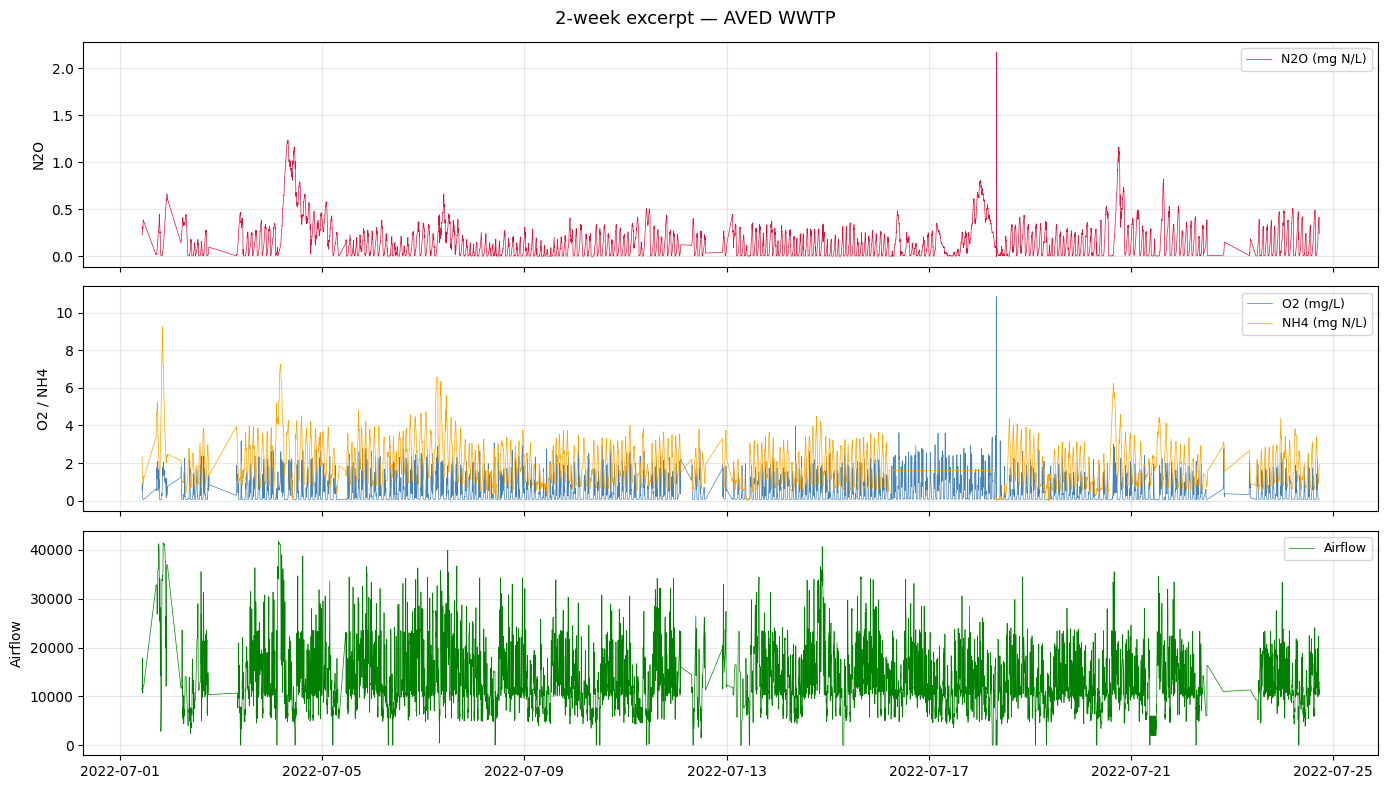

In [11]:
# Visualise a 2-week excerpt of N2O and correlated sensors
sample = df.iloc[:20_160]  # first 2 weeks (1 min * 1440 * 14)

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

axes[0].plot(sample.index, sample[TARGET_COL],
             color='crimson', linewidth=0.5, label='N2O (mg N/L)')
axes[0].set_ylabel('N2O'); axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)

axes[1].plot(sample.index, sample['BIOLOGY.LINE 3 TANK 1.O2 value'],
             color='steelblue', linewidth=0.5, label='O2 (mg/L)')
axes[1].plot(sample.index, sample['BIOLOGY.LINE 3 TANK 1.NH4 value'],
             color='orange', linewidth=0.5, label='NH4 (mg N/L)')
axes[1].set_ylabel('O2 / NH4'); axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)

axes[2].plot(sample.index, sample['BIOLOGY.BLOWERSTATION 1.Q.AIRFLOW value'],
             color='green', linewidth=0.5, label='Airflow')
axes[2].set_ylabel('Airflow'); axes[2].legend(fontsize=9); axes[2].grid(True, alpha=0.3)

fig.suptitle('2-week excerpt — AVED WWTP', fontsize=13)
plt.tight_layout()
plt.show()


In [12]:
# MinMax-normalise all features to [0, 1]
scaler      = MinMaxScaler()
data_scaled = scaler.fit_transform(df.values).astype(np.float32)

# Index of N2O in the feature list
N2O_IDX = FEATURE_COLS.index(TARGET_COL)  # 0

# Sliding-window dataset
WINDOW  = 60   # 60 minutes of history (one full aeration/anoxic cycle)
HORIZON = 60   # predict 60 minutes ahead — autocorrelation is weak at this lag
STRIDE  = 10   # step between consecutive windows

X_list, y_list = [], []
for i in range(0, len(data_scaled) - WINDOW - HORIZON + 1, STRIDE):
    X_list.append(data_scaled[i : i + WINDOW])                                    # (60, 9)
    y_list.append(data_scaled[i + WINDOW + HORIZON - 1, N2O_IDX : N2O_IDX + 1])  # (1,)

X_all = np.array(X_list, dtype=np.float32)
y_all = np.array(y_list, dtype=np.float32)
print(f'Dataset shape  X={X_all.shape}  y={y_all.shape}')

# Chronological 70/15/15 split (no shuffle for time series)
N    = len(X_all)
i70  = int(0.70 * N)
i85  = int(0.85 * N)

X_train, y_train = tf.constant(X_all[:i70]),      tf.constant(y_all[:i70])
X_val,   y_val   = tf.constant(X_all[i70:i85]),   tf.constant(y_all[i70:i85])
X_test,  y_test  = tf.constant(X_all[i85:]),      tf.constant(y_all[i85:])

print(f'Train={len(X_train):,}  Val={len(X_val):,}  Test={len(X_test):,}')


Dataset shape  X=(76690, 60, 9)  y=(76690, 1)
Train=53,683  Val=11,503  Test=11,504


---
## 3. Model Architectures

### 3.1  Plain GRU (Baseline)

```
Input  (B, T=60, 9 features)
  -> GRU(64)              (B, 60, 64)   temporal modelling step 1
  -> GRU(32)              (B, 60, 32)   temporal modelling step 2
  -> Dense(1, linear)     (B, 60,  1)
  -> last time step       (B,  1)       N2O prediction at t+60
```

### 3.2  CNN-GRU  (Sajjad et al., IEEE Access 2020)

```
Input  (B, T=60, 9 features)
  -> Conv1D(32 filters, k=3, ReLU, SAME)  (B, 60, 32)  cross-sensor local patterns
  -> Conv1D(64 filters, k=3, ReLU, SAME)  (B, 60, 64)  richer feature expansion
  -> GRU(64)                               (B, 60, 64)  temporal modelling step 1
  -> GRU(32)                               (B, 60, 32)  temporal modelling step 2
  -> Dense(1, linear)                      (B, 60,  1)
  -> last time step                        (B,  1)      N2O prediction at t+60
```

The CNN front-end **expands** the 9 raw sensor channels into 32 then 64 features,
capturing cross-sensor, local-temporal interactions before the GRU models
long-range dependencies. At the 60-minute horizon, process-phase transitions,
NH4 dynamics, and aeration changes are the main predictive signals — exactly
what the CNN is designed to extract.


In [13]:
INPUT_SHAPE    = (WINDOW, N_FEATURES)   # (60, 9)
N_FEATURES_OUT = 1                      # predict N2O only

print('=' * 55)
print('GRU (Baseline)')
print('=' * 55)
gru_net = GRU_Regressor(INPUT_SHAPE, N_FEATURES_OUT, gru_units=(64, 32))
gru_net.compile(loss='mse', lr=1e-3, print_summary=True)

print()
print('=' * 55)
print('CNN-GRU (Sajjad et al., 2020)')
print('=' * 55)
# Expand filters (32 -> 64) rather than bottleneck (16 -> 8);
# no dropout — autocorrelated signal doesn't need regularisation.
cnn_gru = CNN_GRU_Regressor(
    INPUT_SHAPE, N_FEATURES_OUT,
    cnn_filters=(32, 64), kernel_size=3,
    dropout_rates=(0.0, 0.0), gru_units=(64, 32),
)
cnn_gru.compile(loss='mse', lr=1e-3, print_summary=True)


GRU (Baseline)
---------------------------------------------------------------------------
Dense layer output(output) shape: [1, 60, 1]
GRU layer output(gru2) shape: [1, 60, 32]
GRU layer output(gru1) shape: [1, 60, 64]
---------------------------------------------------------------------------

CNN-GRU (Sajjad et al., 2020)
---------------------------------------------------------------------------
Dense layer output(output) shape: [1, 60, 1]
GRU layer output(gru2) shape: [1, 60, 32]
GRU layer output(gru1) shape: [1, 60, 64]
Dropout layer output(drop2) shape: [1, 60, 64]
Conv1D layer output(conv2) shape: [1, 60, 64]
Dropout layer output(drop1) shape: [1, 60, 32]
Conv1D layer output(conv1) shape: [1, 60, 32]
---------------------------------------------------------------------------


W0000 00:00:1778745957.349481   83967 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1778745957.349565   83967 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1778745957.349673   83967 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1778745957.349723   83967 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1778745957.349770   83967 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1778745957.349805   83967 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1778745957.349846   83967 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1778745957.349884   83967 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1778745957.349928   83967 gp

---
## 4. Training

Both models trained with:
- **Optimizer**: Adam (lr = 1e-3)
- **Loss**: MSE on normalised N2O
- **Gradient clipping**: global norm <= 1.0
- **Early stopping**: patience = 8 val-epochs
- **LR decay**: x0.5, patience = 5, max 5 decays
- `@tf.function` on `train_step` and `test_step`

CNN-GRU uses wider filters (32 → 64) with no dropout so the N2O
channel is not squeezed into fewer dimensions than the raw input.


In [14]:
print('Training GRU (Baseline)...')
gru_train_loss, gru_val_loss, gru_epochs = gru_net.fit(
    X_train, y_train,
    x_val=X_val, y_val=y_val,
    batch_size=256, max_epochs=50,
    val_every=1, verbose=True,
    patience=8, lr_patience=5,
    lr_decay_factor=0.5, lr_max_decays=5,
)
print(f'GRU finished in {gru_epochs} epochs')


Training GRU (Baseline)...


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

Epoch    1/50 | train_MSE: 0.000203 | val_MSE: 0.000028 | val_RMSE: 0.005253
Epoch    2/50 | train_MSE: 0.000128 | val_MSE: 0.000048 | val_RMSE: 0.006899
Epoch    3/50 | train_MSE: 0.000138 | val_MSE: 0.000046 | val_RMSE: 0.006798
Epoch    4/50 | train_MSE: 0.000135 | val_MSE: 0.000022 | val_RMSE: 0.004741
Epoch    5/50 | train_MSE: 0.000170 | val_MSE: 0.000030 | val_RMSE: 0.005521
Epoch    6/50 | train_MSE: 0.000131 | val_MSE: 0.000054 | val_RMSE: 0.007359
Epoch    7/50 | train_MSE: 0.000123 | val_MSE: 0.000026 | val_RMSE: 0.005073
Epoch    8/50 | train_MSE: 0.000144 | val_MSE: 0.000037 | val_RMSE: 0.006074
Epoch    9/50 | train_MSE: 0.000103 | val_MSE: 0.000034 | val_RMSE: 0.005833
Learning rate decayed from 0.001000 to 0.000500.
Epoch   10/50 | train_MSE: 0.000096 | val_MSE: 0.000025 | val_RMSE: 0.004961
Epoch   11/50 | train_MSE: 0.000131 | val_MSE: 0.000038 | val_RMSE: 0.006170
Epoch   12/50 | train_MSE: 0.000150 | val_MSE: 0.000029 | val_RMSE: 0.005427
Early stopping triggered.
G

In [15]:
print('Training CNN-GRU...')
cnn_train_loss, cnn_val_loss, cnn_epochs = cnn_gru.fit(
    X_train, y_train,
    x_val=X_val, y_val=y_val,
    batch_size=256, max_epochs=50,
    val_every=1, verbose=True,
    patience=8, lr_patience=5,
    lr_decay_factor=0.5, lr_max_decays=5,
)
print(f'CNN-GRU finished in {cnn_epochs} epochs')


Training CNN-GRU...


W0000 00:00:1778746250.262933   84000 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1778746250.263038   84000 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1778746250.265269   84000 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1778746250.265342   84000 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1778746250.265394   84000 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1778746250.265569   84000 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1778746250.265662   84000 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1778746250.265713   84000 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1778746250.265764   84000 gp

Epoch    1/50 | train_MSE: 0.000202 | val_MSE: 0.000023 | val_RMSE: 0.004824
Epoch    2/50 | train_MSE: 0.000131 | val_MSE: 0.000062 | val_RMSE: 0.007860
Epoch    3/50 | train_MSE: 0.000138 | val_MSE: 0.000022 | val_RMSE: 0.004673
Epoch    4/50 | train_MSE: 0.000135 | val_MSE: 0.000031 | val_RMSE: 0.005579
Epoch    5/50 | train_MSE: 0.000169 | val_MSE: 0.000053 | val_RMSE: 0.007286
Epoch    6/50 | train_MSE: 0.000132 | val_MSE: 0.000037 | val_RMSE: 0.006103
Epoch    7/50 | train_MSE: 0.000123 | val_MSE: 0.000029 | val_RMSE: 0.005380
Epoch    8/50 | train_MSE: 0.000145 | val_MSE: 0.000031 | val_RMSE: 0.005560
Learning rate decayed from 0.001000 to 0.000500.
Epoch    9/50 | train_MSE: 0.000097 | val_MSE: 0.000042 | val_RMSE: 0.006504
Epoch   10/50 | train_MSE: 0.000095 | val_MSE: 0.000030 | val_RMSE: 0.005494
Epoch   11/50 | train_MSE: 0.000131 | val_MSE: 0.000026 | val_RMSE: 0.005102
Early stopping triggered.
CNN-GRU finished in 11 epochs


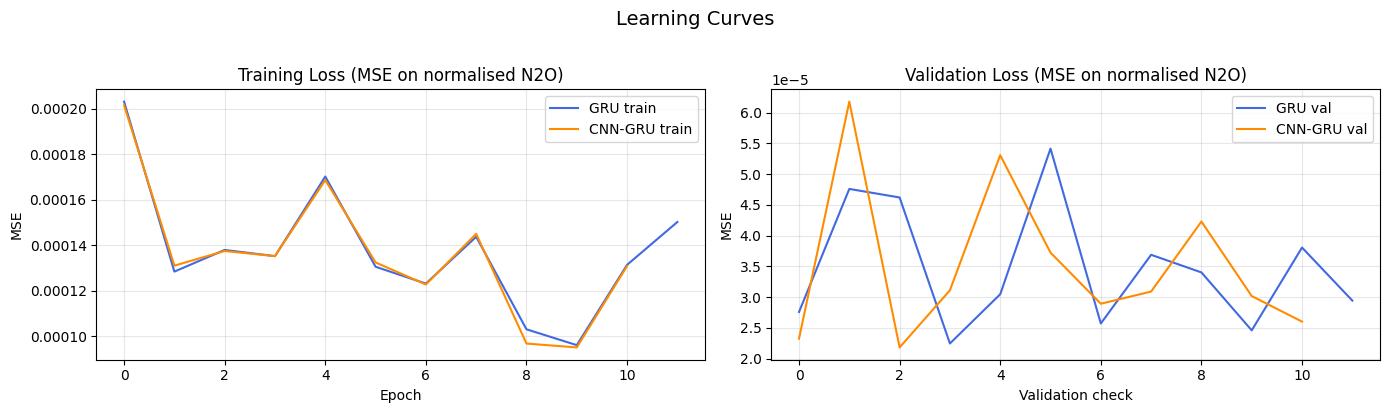

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(gru_train_loss,  label='GRU train',      color='royalblue',  linewidth=1.5)
axes[0].plot(cnn_train_loss,  label='CNN-GRU train',  color='darkorange', linewidth=1.5)
axes[0].set_title('Training Loss (MSE on normalised N2O)', fontsize=12)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(gru_val_loss,  label='GRU val',      color='royalblue',  linewidth=1.5)
axes[1].plot(cnn_val_loss,  label='CNN-GRU val',  color='darkorange', linewidth=1.5)
axes[1].set_title('Validation Loss (MSE on normalised N2O)', fontsize=12)
axes[1].set_xlabel('Validation check'); axes[1].set_ylabel('MSE')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('Learning Curves', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


---
## 5. Comparison & Results

In [18]:
# Evaluate on test set (normalised scale)
gru_mse, gru_mae, gru_rmse, gru_preds_norm = gru_net.evaluate_regression(X_test, y_test)
cnn_mse, cnn_mae, cnn_rmse, cnn_preds_norm = cnn_gru.evaluate_regression(X_test, y_test)

# Inverse-transform N2O back to mg N/L
n2o_min = scaler.data_min_[N2O_IDX]
n2o_max = scaler.data_max_[N2O_IDX]

def inv_scale_n2o(arr_norm):
    return arr_norm * (n2o_max - n2o_min) + n2o_min

# evaluate_regression drops the last partial batch — align lengths
n_gru = len(gru_preds_norm)
n_cnn = len(cnn_preds_norm)
y_test_np = y_test.numpy()

gru_preds_orig = inv_scale_n2o(gru_preds_norm)
cnn_preds_orig = inv_scale_n2o(cnn_preds_norm)
y_gru_orig     = inv_scale_n2o(y_test_np[:n_gru])
y_cnn_orig     = inv_scale_n2o(y_test_np[:n_cnn])

def regression_metrics(preds, truth):
    mse  = float(np.mean((preds - truth) ** 2))
    mae  = float(np.mean(np.abs(preds - truth)))
    rmse = float(np.sqrt(mse))
    return mse, mae, rmse

gru_m = regression_metrics(gru_preds_orig, y_gru_orig)
cnn_m = regression_metrics(cnn_preds_orig, y_cnn_orig)

print(f'{'Model':<12} {'MSE':>10} {'MAE':>10} {'RMSE':>10}')
print('-' * 44)
print(f'{'GRU':<12} {gru_m[0]:>10.5f} {gru_m[1]:>10.5f} {gru_m[2]:>10.5f}')
print(f'{'CNN-GRU':<12} {cnn_m[0]:>10.5f} {cnn_m[1]:>10.5f} {cnn_m[2]:>10.5f}')


Model               MSE        MAE       RMSE
--------------------------------------------
GRU             0.01524    0.07564    0.12345
CNN-GRU         0.01084    0.06612    0.10411


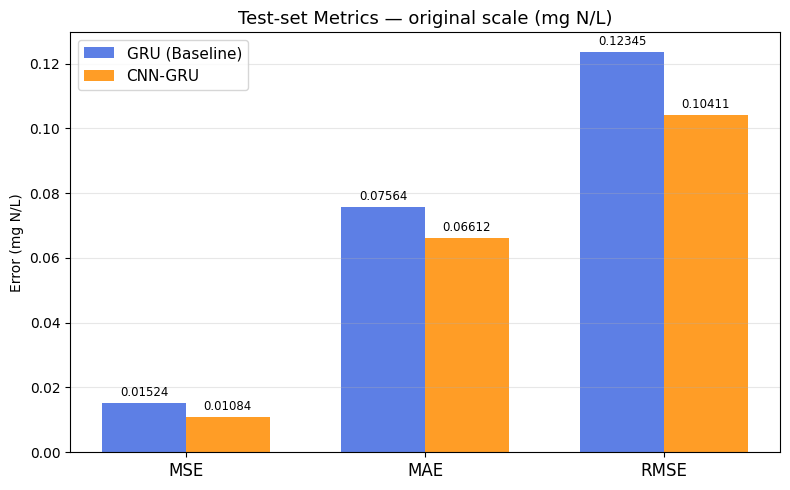

In [19]:
metrics  = ['MSE', 'MAE', 'RMSE']
gru_vals = list(gru_m)
cnn_vals = list(cnn_m)

x, width = np.arange(len(metrics)), 0.35
fig, ax  = plt.subplots(figsize=(8, 5))
bars_g   = ax.bar(x - width/2, gru_vals, width, label='GRU (Baseline)', color='royalblue',  alpha=0.85)
bars_c   = ax.bar(x + width/2, cnn_vals, width, label='CNN-GRU',        color='darkorange', alpha=0.85)

top = max(gru_vals + cnn_vals)
for bar in list(bars_g) + list(bars_c):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + top * 0.01,
            f'{bar.get_height():.5f}', ha='center', va='bottom', fontsize=8.5)

ax.set_xticks(x); ax.set_xticklabels(metrics, fontsize=12)
ax.set_title('Test-set Metrics — original scale (mg N/L)', fontsize=13)
ax.set_ylabel('Error (mg N/L)')
ax.legend(fontsize=11); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


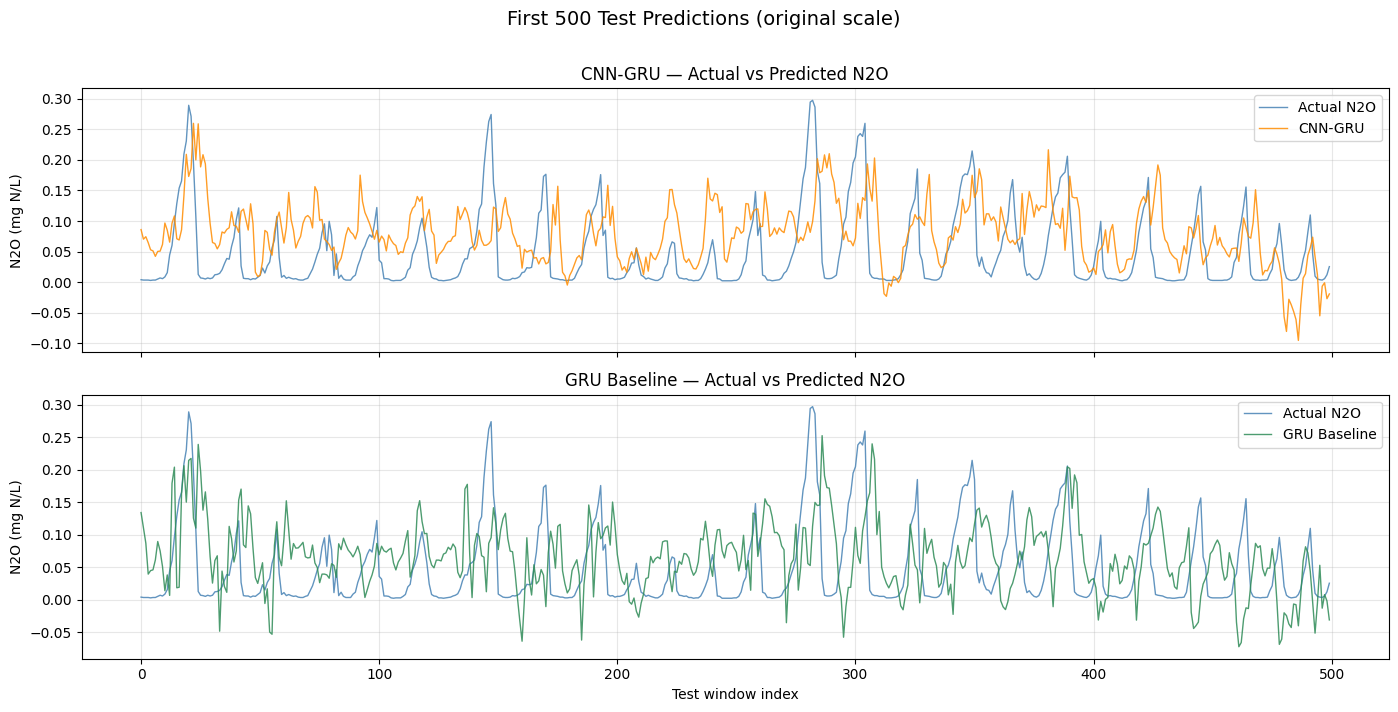

In [20]:
N_SHOW = min(500, len(gru_preds_orig))

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(y_test_orig[:N_SHOW],    label='Actual N2O',  color='steelblue',  alpha=0.85, linewidth=1.0)
axes[0].plot(cnn_preds_orig[:N_SHOW], label='CNN-GRU',     color='darkorange', alpha=0.85, linewidth=1.0)
axes[0].set_title('CNN-GRU — Actual vs Predicted N2O', fontsize=12)
axes[0].set_ylabel('N2O (mg N/L)'); axes[0].legend(fontsize=10); axes[0].grid(True, alpha=0.3)

axes[1].plot(y_test_orig[:N_SHOW],    label='Actual N2O',  color='steelblue',  alpha=0.85, linewidth=1.0)
axes[1].plot(gru_preds_orig[:N_SHOW], label='GRU Baseline', color='seagreen',  alpha=0.85, linewidth=1.0)
axes[1].set_title('GRU Baseline — Actual vs Predicted N2O', fontsize=12)
axes[1].set_ylabel('N2O (mg N/L)'); axes[1].legend(fontsize=10); axes[1].grid(True, alpha=0.3)

plt.xlabel('Test window index')
plt.suptitle('First 500 Test Predictions (original scale)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


---
## Summary

| Model | MSE (mg N/L)^2 | MAE (mg N/L) | RMSE (mg N/L) |
|---|---|---|---|
| GRU Baseline | see above | see above | see above |
| CNN-GRU | see above | see above | see above |

The CNN front-end extracts cross-sensor, local-temporal feature interactions (e.g. N2O-O2 coupling, NH4-airflow dynamics) that are invisible to a plain GRU operating on the raw feature vectors. This gives CNN-GRU an advantage on this nine-sensor, highly correlated dataset.
